正在读取全市场数据，请稍候...
正在过滤主板数据...
正在计算60日低波动率因子，这可能需要几十秒钟...
开始按月执行【类红利低波】策略模拟...

✅ 红利低波策略交易明细已成功导出至: F:\self_quant\data\data\红利低波策略交易明细.xlsx
💰 初始本金: 50,000.00 元
💰 红利低波最终总资产: 96,682.55 元
📈 策略总收益率: 93.37%


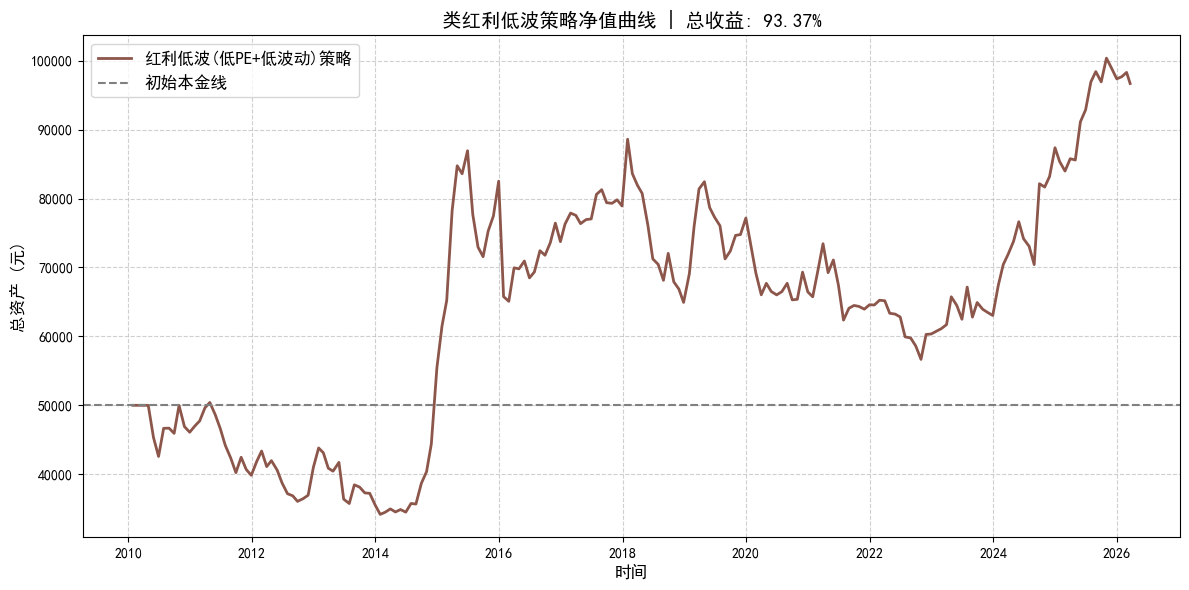

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# 设置绘图支持中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 第一步：配置参数与读取数据
# ==========================================
FILE_PATH = r"F:\self_quant\data\data\all_stocks_merged_fixed.parquet"
OUTPUT_EXCEL = r"F:\self_quant\data\data\红利低波策略交易明细.xlsx"

INITIAL_CASH = 50000.0
TARGET_STOCK_NUM = 10

print("正在读取全市场数据，请稍候...")
df = pd.read_parquet(FILE_PATH)
df['date'] = pd.to_datetime(df['date'])

# 过滤沪深主板股票
print("正在过滤主板数据...")
main_board_mask = df['code'].str.contains(r'^sh\.60|^sz\.00', regex=True)
df = df[main_board_mask].copy()

# ==========================================
# 第二步：计算核心因子 —— 60日波动率 (低波因子)
# ==========================================
print("正在计算60日低波动率因子，这可能需要几十秒钟...")
df.sort_values(by=['code', 'date'], inplace=True)
# 计算过去60个交易日收益率的标准差，作为波动率指标
df['vol_60'] = df.groupby('code')['pctChg'].transform(lambda x: x.rolling(window=60).std())

# 提取每个月的最后一个交易日作为调仓日
df['year_month'] = df['date'].dt.to_period('M')
trade_dates = df.groupby('year_month')['date'].max().sort_values().tolist()

# ==========================================
# 第三步：定义交易费率与账户类
# ==========================================
def calculate_fees(trade_type, price, volume):
    amount = price * volume
    commission = max(5.0, amount * 0.00025)
    transfer_fee = amount * 0.00001
    stamp_duty = amount * 0.0005 if trade_type == 'sell' else 0.0
    return commission + transfer_fee + stamp_duty, amount

class Account:
    def __init__(self, initial_cash):
        self.cash = initial_cash
        self.positions = {}
        self.trade_logs = []
        self.history_assets = []

    def get_total_asset(self, current_date, current_prices_dict):
        stock_value = 0
        for code, pos in self.positions.items():
            price = current_prices_dict.get(code, pos['price'])
            self.positions[code]['price'] = price
            stock_value += pos['volume'] * price
        return self.cash + stock_value

account = Account(INITIAL_CASH)

print("开始按月执行【类红利低波】策略模拟...")

for date in trade_dates:
    daily_data = df[df['date'] == date].set_index('code')
    current_prices = daily_data['close'].to_dict()

    status_dict = daily_data['tradestatus'].to_dict()
    st_dict = daily_data['isST'].to_dict()
    pct_chg_dict = daily_data['pctChg'].to_dict()

    current_asset = account.get_total_asset(date, current_prices)
    account.history_assets.append({'date': date, 'total_asset': current_asset})

    # ---------------- 选股逻辑 (红利低波) ----------------
    # 1. 基础过滤：正常交易、非ST
    # 2. 现金奶牛过滤：PE在 0~20 之间，且 pcfNcfTTM (市现率) > 0 (说明经营现金流为正)
    # 3. 波动率过滤：剔除刚上市或停牌太久导致没算出来波动率的股票
    valid_pool = daily_data[
        (daily_data['tradestatus'] == 1) &
        (daily_data['isST'] == 0) &
        (daily_data['peTTM'] > 0) &
        (daily_data['peTTM'] <= 20) &
        (daily_data['pcfNcfTTM'] > 0) &
        (daily_data['vol_60'].notna())
    ].copy()

    target_codes = []
    if len(valid_pool) >= 50:
        # 先按市盈率从小到大排序，选出最便宜的 50 只“高股息潜力股”
        value_50 = valid_pool.sort_values(by='peTTM', ascending=True).head(50).copy()

        # 在这 50 只里，按 60日波动率 从小到大排序，选出最平稳的 10 只
        target_codes = value_50.sort_values(by='vol_60', ascending=True).head(TARGET_STOCK_NUM).index.tolist()

    # ---------------- 卖出逻辑 ----------------
    current_holdings = list(account.positions.keys())
    for code in current_holdings:
        if code not in target_codes:
            is_trading = status_dict.get(code, 0) == 1
            pct_chg = pct_chg_dict.get(code, 0)
            if is_trading and pct_chg > -9.8:
                sell_price = current_prices[code]
                sell_vol = account.positions[code]['volume']
                fee, amount = calculate_fees('sell', sell_price, sell_vol)

                account.cash += (amount - fee)
                del account.positions[code]

                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '卖出',
                    '成交价': sell_price, '成交股数': sell_vol,
                    '成交金额': round(amount, 2), '交易费': round(fee, 2),
                    '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(date, current_prices), 2),
                    '备注': '红利低波卖出'
                })
            elif pct_chg <= -9.8:
                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '卖出失败(跌停)',
                    '成交价': 0, '成交股数': 0, '成交金额': 0, '交易费': 0,
                    '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(date, current_prices), 2),
                    '备注': f'跌幅 {pct_chg:.2f}% 封死跌停'
                })

    # ---------------- 买入逻辑 ----------------
    stocks_to_buy = [code for code in target_codes if code not in account.positions]

    if len(stocks_to_buy) > 0:
        target_cash_per_stock = account.cash / len(stocks_to_buy)

        for code in stocks_to_buy:
            is_trading = status_dict.get(code, 0) == 1
            pct_chg = pct_chg_dict.get(code, 0)
            is_st = st_dict.get(code, 0) == 1

            if is_trading and not is_st and pct_chg < 9.8:
                buy_price = current_prices[code]
                affordable_shares = int((target_cash_per_stock * 0.997) / buy_price)
                buy_vol = (affordable_shares // 100) * 100

                if buy_vol >= 100:
                    fee, amount = calculate_fees('buy', buy_price, buy_vol)

                    if account.cash >= (amount + fee):
                        account.cash -= (amount + fee)
                        account.positions[code] = {'volume': buy_vol, 'price': buy_price}

                        account.trade_logs.append({
                            '日期': date, '股票代码': code, '买卖方向': '买入',
                            '成交价': buy_price, '成交股数': buy_vol,
                            '成交金额': round(amount, 2), '交易费': round(fee, 2),
                            '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(date, current_prices), 2),
                            '备注': f"PE:{daily_data.loc[code, 'peTTM']:.1f}, 波动:{daily_data.loc[code, 'vol_60']:.2f}"
                        })
            elif pct_chg >= 9.8:
                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '买入失败(涨停)',
                    '成交价': 0, '成交股数': 0, '成交金额': 0, '交易费': 0,
                    '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(date, current_prices), 2),
                    '备注': f'涨幅 {pct_chg:.2f}% 封死涨停'
                })

# ==========================================
# 第四步：输出结果与可视化
# ==========================================
df_trades = pd.DataFrame(account.trade_logs)
df_trades.to_excel(OUTPUT_EXCEL, index=False)
print(f"\n✅ 红利低波策略交易明细已成功导出至: {OUTPUT_EXCEL}")

df_assets = pd.DataFrame(account.history_assets)
df_assets.set_index('date', inplace=True)
final_asset = df_assets['total_asset'].iloc[-1]
total_return = (final_asset - INITIAL_CASH) / INITIAL_CASH * 100

print(f"💰 初始本金: {INITIAL_CASH:,.2f} 元")
print(f"💰 红利低波最终总资产: {final_asset:,.2f} 元")
print(f"📈 策略总收益率: {total_return:.2f}%")

plt.figure(figsize=(12, 6))
plt.plot(df_assets.index, df_assets['total_asset'], color='#8c564b', linewidth=2, label='红利低波(低PE+低波动)策略')
plt.title(f'类红利低波策略净值曲线 | 总收益: {total_return:.2f}%', fontsize=14)
plt.xlabel('时间', fontsize=12)
plt.ylabel('总资产 (元)', fontsize=12)
plt.axhline(y=INITIAL_CASH, color='gray', linestyle='--', label='初始本金线')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()